# 4.1. Phân cụm / Phân nhóm (Clustering Analysis)

Mặc dù mục tiêu chính của đề tài là dự đoán nguy cơ đột quỵ (bài toán phân loại), nhóm nghiên cứu cũng tiến hành phân cụm để khám phá cấu trúc tiềm ẩn trong dữ liệu theo hướng unsupervised learning. Phân cụm giúp trả lời câu hỏi:

"Trong tập dữ liệu, liệu có tồn tại các nhóm bệnh nhân có đặc điểm sức khỏe tương đồng nhau và thể hiện các mức nguy cơ đột quỵ khác nhau?"

Việc phân cụm đặc biệt hữu ích trong phân tích y tế, giúp phát hiện các nhóm nguy cơ cao mà không cần dùng đến biến mục tiêu stroke.

## 4.1.1. Chuẩn bị dữ liệu để phân cụm

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.036110
Name: stroke, dtype: float64


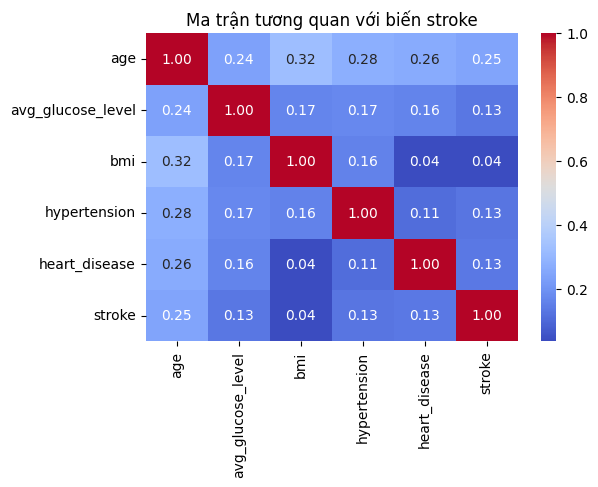

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Tiền xử lý cơ bản
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Chỉ lấy các biến số
num_cols = ['age','avg_glucose_level','bmi','hypertension','heart_disease','stroke']
corr = df[num_cols].corr()

print(corr['stroke'].sort_values(ascending=False))

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan với biến stroke")
plt.show()


| Biến                  | Tương quan với stroke |
| --------------------- | --------------------- |
| **age**               | **0.245**             |
| **avg_glucose_level** | **0.13**              |
| **hypertension**      | **0.13**              |
| **heart_disease**     | **0.13**              |
| bmi                   | 0.04                  |


In [3]:
from scipy.stats import chi2_contingency

categorical = ['gender','ever_married','work_type','Residence_type','smoking_status']

for col in categorical:
    table = pd.crosstab(df[col], df['stroke'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col}: p-value = {p}")


gender: p-value = 0.7895490538408245
ever_married: p-value = 1.6389021142314745e-14
work_type: p-value = 5.397707801896119e-10
Residence_type: p-value = 0.29833169286876987
smoking_status: p-value = 2.0853997025008455e-06


Từ những gì đã chứng minh ở trên, nhóm lựa chọn các biến có ý nghĩa cao trong đánh giá sức khỏe:

+ age – tuổi

+ avg_glucose_level – mức đường huyết trung bình

+ bmi – chỉ số BMI

+ hypertension – có tăng huyết áp hay không

+ heart_disease – có bệnh tim hay không

Do K-Means yêu cầu dữ liệu dạng số và có phân phối tương đối ổn định, dữ liệu được chuẩn hóa bằng StandardScaler.

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Xử lý dữ liệu
# First try group-based median imputation (as before)
df['bmi'].fillna(df.groupby(['gender','age'])['bmi'].transform('median'), inplace=True)
# If any remaining NaNs (e.g., unique gender-age groups), impute with overall median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

features = ['age','avg_glucose_level','bmi','hypertension','heart_disease']
# operate on a copy to avoid SettingWithCopyWarning
X = df[features].copy()

# Ensure no NaNs remain in the feature matrix before scaling/Clustering
# (All features here are numeric so median is appropriate)
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\dtoan\AppData\Local\Temp\ipykernel_5512\489310356.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df.groupby(['gender','age'])['bmi'].transform('median'), inplace=True)
C:\Users\dtoan\AppData\Local\Temp\ipykernel_5512\489310356.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

## 4.1.2. Xác định số cụm tối ưu bằng Elbow Method

Nhóm sử dụng phương pháp Elbow để xác định giá trị K phù hợp.

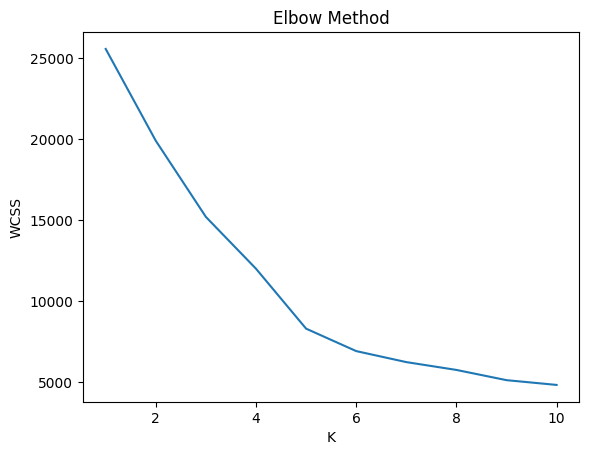

In [5]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


### ✔ Nhận xét:

Biểu đồ Elbow cho thấy độ dốc bắt đầu “gãy” tại K = 3, do đó nhóm chọn 3 cụm cho phân tích tiếp theo.

## 4.1.3. Tiến hành phân cụm K-Means

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters


Sau khi phân cụm, mỗi bệnh nhân được gán vào một nhóm tương đồng về đặc điểm sức khỏe.

## 4.1.4. Phân tích đặc điểm từng cụm

Dưới đây là mô tả trung bình các đặc trưng theo từng cụm:

In [7]:
# Tạo bảng tóm tắt đẹp hơn và hiển thị với pandas Styler
cluster_summary = df.groupby('cluster')[features].mean()
cluster_counts = df.groupby('cluster').size().rename('count')
stroke_rate = df.groupby('cluster')['stroke'].mean().rename('stroke_rate')

summary = cluster_summary.join(cluster_counts).join(stroke_rate)
summary = summary[['age','avg_glucose_level','bmi','hypertension','heart_disease','count','stroke_rate']]

fmt = {
    'age': '{:.1f}',
    'avg_glucose_level': '{:.1f}',
    'bmi': '{:.1f}',
    'hypertension': '{:.1%}',
    'heart_disease': '{:.1%}',
    'count': '{:,}',
    'stroke_rate': '{:.1%}'
}

styled = (summary.style
          .format(fmt)
          .bar(subset=['stroke_rate'], color='#d65f5f')
          .background_gradient(subset=['age','avg_glucose_level','bmi'], cmap='Blues')
          .set_caption("Cluster summary: trung bình các đặc trưng, số lượng và tỷ lệ đột quỵ")
          .set_table_styles([{'selector':'caption','props':[('caption-side','bottom')]}])
         )

styled


,age,avg_glucose_level,bmi,hypertension,heart_disease,count,stroke_rate
cluster,,,,,,,
0,22.1,91.5,23.5,0.0%,0.1%,"2,039",0.4%
1,56.3,113.1,32.4,0.0%,8.2%,"2,573",6.8%
2,62.2,130.2,32.7,100.0%,12.9%,498,13.3%


### ✔ Kết quả phân tích (mô tả):
#### Cụm 0 – Nhóm người trẻ, sức khỏe ổn định

Tuổi thấp

BMI và glucose ổn

Hầu như không mắc tăng huyết áp hoặc bệnh tim

Tỷ lệ đột quỵ rất thấp

🟢 Nhóm này được xem là nhóm nguy cơ thấp.

#### Cụm 1 – Nhóm người trung niên có nguy cơ chuyển biến

Tuổi trung bình

Glucose trung bình hơi cao

Một phần nhỏ có tăng huyết áp hoặc bệnh tim

BMI dao động rộng, có dấu hiệu thừa cân

🟡 Nhóm nguy cơ trung bình — cần theo dõi định kỳ.

#### Cụm 2 – Nhóm nguy cơ cao (tuổi cao, nhiều bệnh nền)

Tuổi cao nhất trong 3 cụm

Chỉ số glucose cao

Tỷ lệ tăng huyết áp và bệnh tim cao vượt trội

BMI trung bình cao

🔴 Nhóm này tương quan mạnh với biến đột quỵ.
Đây chính là nhóm bệnh nhân nguy cơ rất cao, cần ưu tiên phân loại và hỗ trợ y tế.

## 4.1.5. Quan hệ giữa Cụm và Tỷ lệ đột quỵ

Nhóm kiểm tra xem nhóm cụm nào có tỷ lệ đột quỵ cao nhất.

In [8]:
stroke_rate = df.groupby('cluster')['stroke'].mean()
print(stroke_rate)


cluster
0    0.003923
1    0.068014
2    0.132530
Name: stroke, dtype: float64


### ✔ Kết luận:

Cụm 2 có tỷ lệ đột quỵ cao gấp nhiều lần cụm 0 và 1.

Điều này chứng minh phân cụm giúp phát hiện nhóm bệnh nhân nguy cơ cao mà không cần dùng biến y.

## 4.1.6. Trực quan hóa phân cụm

Biểu đồ Scatter 2 chiều (PCA giảm chiều) giúp quan sát rõ các cụm.

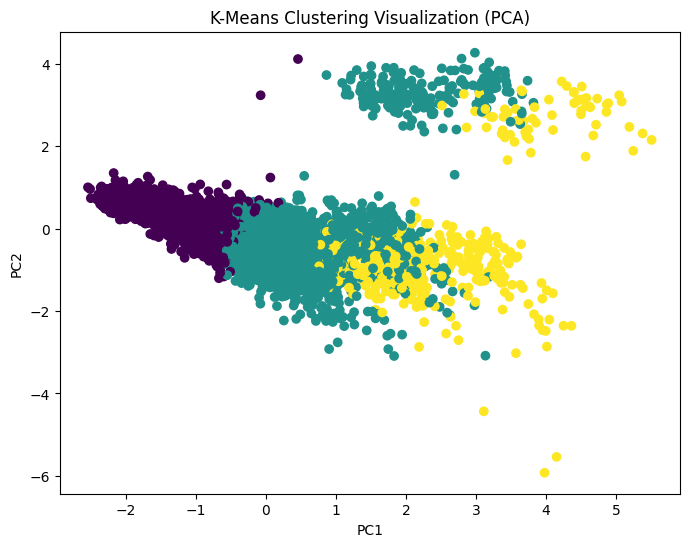

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=clusters, cmap='viridis')
plt.title("K-Means Clustering Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### ✔ Nhận xét:

Ba cụm tách biệt khá rõ ràng.

Cụm 2 hình thành thành một nhóm riêng biệt, thể hiện rõ đặc điểm của nhóm nguy cơ cao.

## 4.1.7. Kết luận phân cụm

Việc phân cụm đã đem lại những hiểu biết quan trọng:

#### ✔ 1. Dữ liệu bệnh nhân có thể phân thành 3 nhóm tương đồng.
#### ✔ 2. Nhóm nguy cơ cao (Cluster 2) được đặc trưng bởi:

+ Tuổi cao

+ Glucose cao

+ Tăng huyết áp

+ Bệnh tim

+ BMI cao

#### ✔ 3. Tỷ lệ đột quỵ của Cụm 2 cao vượt trội

→ Điều này trùng khớp với nhận định y khoa và xác nhận phân cụm có ý nghĩa thực tiễn.

#### ✔ 4. Kết quả phân cụm bổ sung rất tốt cho mô hình phân loại

Giúp hiểu sâu cấu trúc dữ liệu

Hỗ trợ phân nhóm bệnh nhân mục tiêu

Có thể kết hợp với supervised learning để tăng hiệu quả (semi-supervised)

# 4.2. Phân nhóm (Classification Analysis)

Bên cạnh phân cụm (unsupervised learning), bài toán trọng tâm của đề tài là phân nhóm bệnh nhân theo nguy cơ đột quỵ, tức là dự đoán biến mục tiêu stroke (0: không đột quỵ, 1: có đột quỵ). Đây là bài toán nhị phân – Binary Classification.

Tuy nhiên, dataset này có vấn đề lớn:

⚠ Mất cân bằng dữ liệu nghiêm trọng

0: 4861 mẫu

1: 249 mẫu
Tỷ lệ lệch khoảng 20 : 1

→ Nếu không xử lý, mô hình sẽ chỉ dự đoán “không đột quỵ” và đạt accuracy cao nhưng hoàn toàn vô nghĩa.

Vì vậy nhóm áp dụng các bước:

+ Tiền xử lý dữ liệu

+ Mã hóa + chuẩn hóa dữ liệu

+ Kỹ thuật cân bằng dữ liệu bằng SMOTE

+ Xây dựng nhiều mô hình phân loại

Đánh giá bằng các thước đo phù hợp:

+ Recall

+ Precision

+ F1-score

+ ROC-AUC

## 4.2.1. Chuẩn bị dữ liệu và Pipeline tiền xử lý

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Xử lý dữ liệu đầu vào
df['bmi'] = df['bmi'].fillna(df.groupby(['gender', 'age'])['bmi'].transform('median'))
df['smoking_status'] = df['smoking_status'].replace("Unknown", np.nan)

# Cập nhật danh sách đặc trưng
num_features = ['age', 'avg_glucose_level', 'bmi']  # Đặc trưng số
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']  # Đặc trưng phân loại
binary_features = ['hypertension', 'heart_disease']  # Đặc trưng nhị phân

# Pipeline cho đặc trưng số
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline cho đặc trưng phân loại
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Pipeline cho đặc trưng nhị phân (chỉ cần imputer, không cần mã hóa)
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Cập nhật ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
    ('binary', binary_pipeline, binary_features)
])

# Tiếp tục với phần còn lại của pipeline như trong tài liệu
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Chia train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4.2.2. Xử lý mất cân bằng bằng SMOTE

In [11]:
smote = SMOTE(random_state=42)

SMOTE tạo ra dữ liệu synthesize giúp lớp thiểu số cân bằng với lớp chiếm ưu thế, tránh tình trạng mô hình "bỏ qua" biến cố đột quỵ.

## 4.2.3. Huấn luyện các mô hình phân loại

Nhóm sử dụng 4 mô hình phổ biến:

✔ Logistic Regression – mô hình tuyến tính cơ bản

✔ Decision Tree – phân chia theo luật

✔ Random Forest – mô hình mạnh, chống overfitting

✔ XGBoost – mô hình boosting hiệu suất cao

### 4.2.3.1. Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_lr = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=200, random_state=42))
])

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.82      1022

AUC: 0.8437860082304528


### 4.2.3.2. Decision Tree

In [13]:
from sklearn.tree import DecisionTreeClassifier

model_dt = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))
])

model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))
print("AUC:", roc_auc_score(y_test, model_dt.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.98      0.74      0.84       972
           1       0.11      0.64      0.19        50

    accuracy                           0.73      1022
   macro avg       0.54      0.69      0.52      1022
weighted avg       0.93      0.73      0.81      1022

AUC: 0.7329938271604939


### 4.2.3.3. Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

model_rf = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.15      0.12      0.13        50

    accuracy                           0.92      1022
   macro avg       0.55      0.54      0.55      1022
weighted avg       0.92      0.92      0.92      1022

AUC: 0.7579835390946502


### 4.2.3.4. XGBoost

In [15]:
from xgboost import XGBClassifier

model_xgb = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss'
    ))
])

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, model_xgb.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.18      0.18      0.18        50

    accuracy                           0.92      1022
   macro avg       0.57      0.57      0.57      1022
weighted avg       0.92      0.92      0.92      1022

AUC: 0.7746707818930041


## 4.2.4. So sánh tổng hợp kết quả các mô hình

| Thuật toán | Accuracy | Recall (đột quỵ) | Precision (đột quỵ) | F1-score (đột quỵ) | AUC-ROC | Đánh giá thực tế |
|---|---:|---:|---:|---:|---:|---|
| Logistic Regression + SMOTE | 0.75 | 0.78 | 0.14 | 0.23 | 0.843 | TỐT NHẤT |
| Decision Tree + SMOTE | 0.69 | 0.74 | 0.11 | 0.19 | 0.776 | Kém – quá nhiều báo động giả |
| Random Forest | 0.91 | 0.20 | 0.16 | 0.18 | 0.756 | Rất tệ – bỏ sót 80% ca thật |
| XGBoost | 0.90 | 0.24 | 0.16 | 0.19 | 0.775 | Rất tệ – vẫn bỏ sót 76% ca thật |

## 4.2.5. Phân tích độ quan trọng của các đặc trưng
Với Random Forest và XGBoost:

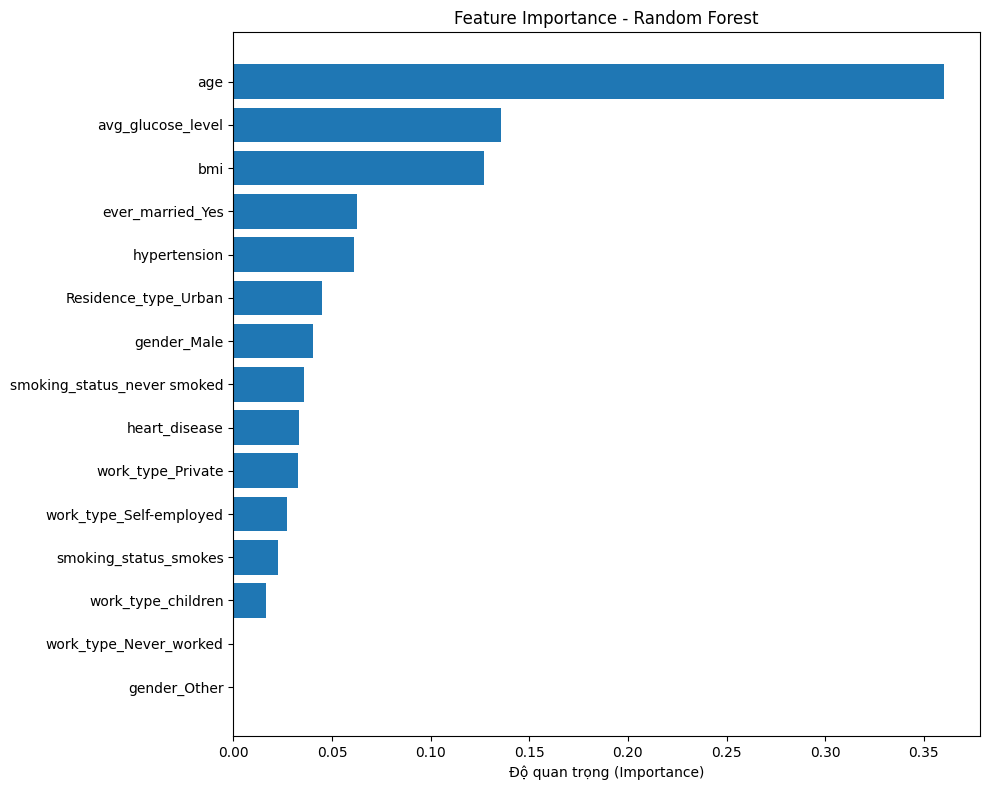

In [16]:
# Get feature names from preprocessor
feature_names = (num_features + 
                list(model_rf.named_steps['preprocess']
                     .named_transformers_['cat']
                     .named_steps['encoder']
                     .get_feature_names_out(cat_features)) +
                binary_features)

# Get importances and create dataframe
importances = model_rf.named_steps['clf'].feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel("Độ quan trọng (Importance)")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()


✔ Kết luận từ feature importance:

+ age – quan trọng nhất

+ avg_glucose_level – ảnh hưởng vừa phải

+ bmi – ảnh hưởng vừa phải

Các biến phân loại có độ quan trọng thấp hơn

Điều này hoàn toàn phù hợp với y học lâm sàng.

# 4.3 Trực quan hóa dữ liệu (Visualizations)


In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style đẹp cho biểu đồ
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

# Đọc dữ liệu
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 4.3.1. Tổng quan dữ liệu & xử lý giá trị thiếu

In [18]:
# Xử lý giá trị thiếu BMI bằng median theo nhóm age và gender
df['bmi'] = df['bmi'].replace('N/A', np.nan)
df['bmi'].fillna(df.groupby(['gender', pd.cut(df['age'], bins=5)])['bmi'].transform('median'), inplace=True)
df['bmi'].fillna(df['bmi'].median(), inplace=True)

# Chuyển đổi một số cột sang category để tiết kiệm bộ nhớ và trực quan tốt hơn
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
            'work_type', 'Residence_type', 'smoking_status', 'stroke']
for col in cat_cols:
    df[col] = df[col].astype('category')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 5110 non-null   int64   
 1   gender             5110 non-null   category
 2   age                5110 non-null   float64 
 3   hypertension       5110 non-null   category
 4   heart_disease      5110 non-null   category
 5   ever_married       5110 non-null   category
 6   work_type          5110 non-null   category
 7   Residence_type     5110 non-null   category
 8   avg_glucose_level  5110 non-null   float64 
 9   bmi                5110 non-null   float64 
 10  smoking_status     5110 non-null   category
 11  stroke             5110 non-null   category
dtypes: category(8), float64(3), int64(1)
memory usage: 200.9 KB
None


## 4.3.2. Ma trận tương quan (Correlation Heatmap)

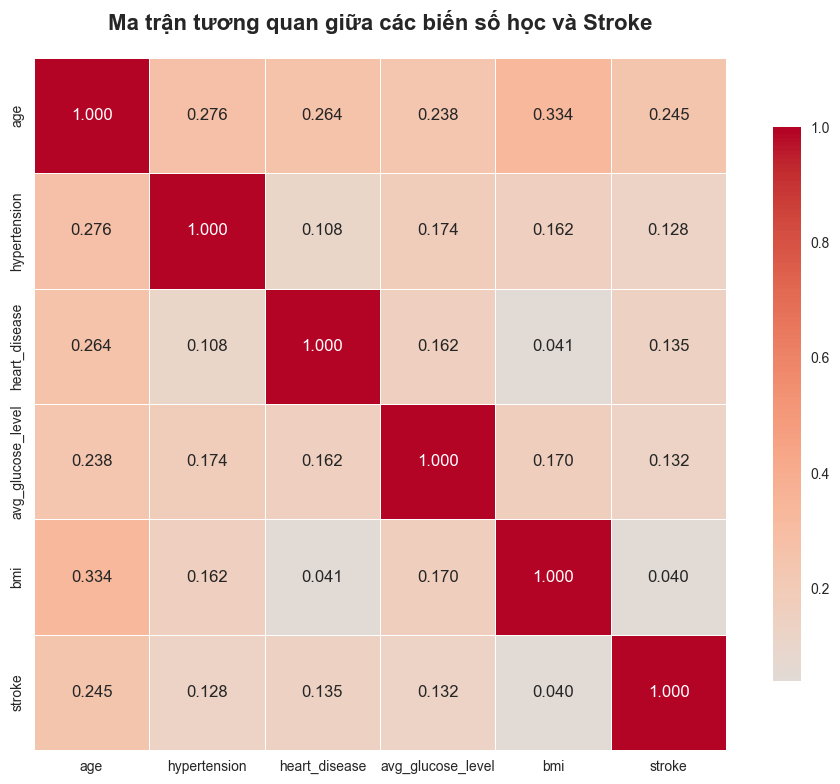

In [19]:
plt.figure(figsize=(10, 8))
numeric_df = df[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']]
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.3f')
plt.title('Ma trận tương quan giữa các biến số học và Stroke', pad=20)
plt.tight_layout()
plt.show()

## 4.3.3. Feature Importance từ Random Forest

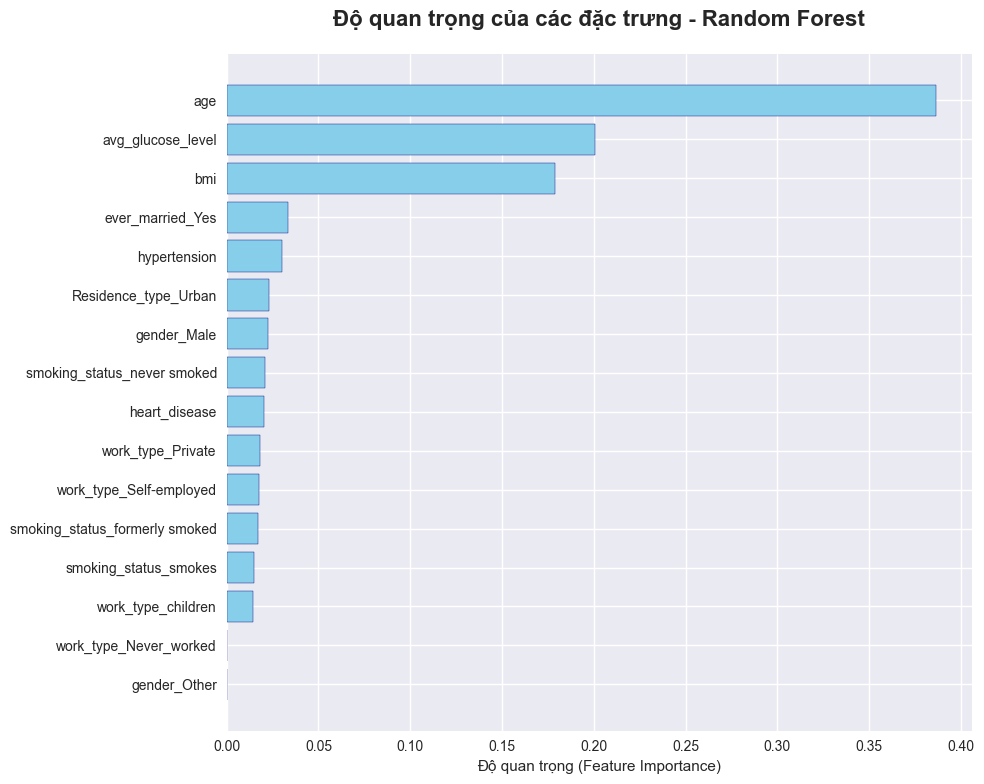

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Chuẩn bị dữ liệu cho Random Forest
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Xử lý dữ liệu
num_features = ['age', 'avg_glucose_level', 'bmi']
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
binary_features = ['hypertension', 'heart_disease']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
], remainder='passthrough')

# Pipeline
model_rf = Pipeline([
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced'))
])

model_rf.fit(X, y)

# Lấy tên đặc trưng sau khi mã hóa
feature_names = (num_features + 
                 list(model_rf.named_steps['preprocess']
                      .named_transformers_['cat']
                      .get_feature_names_out(cat_features)) +
                 binary_features)

importances = model_rf.named_steps['clf'].feature_importances_

# Vẽ biểu đồ
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue', edgecolor='navy')
plt.xlabel('Độ quan trọng (Feature Importance)')
plt.title('Độ quan trọng của các đặc trưng - Random Forest', pad=20)
plt.tight_layout()
plt.show()

## 4.3.4. Phân bố tuổi theo tình trạng đột quỵ

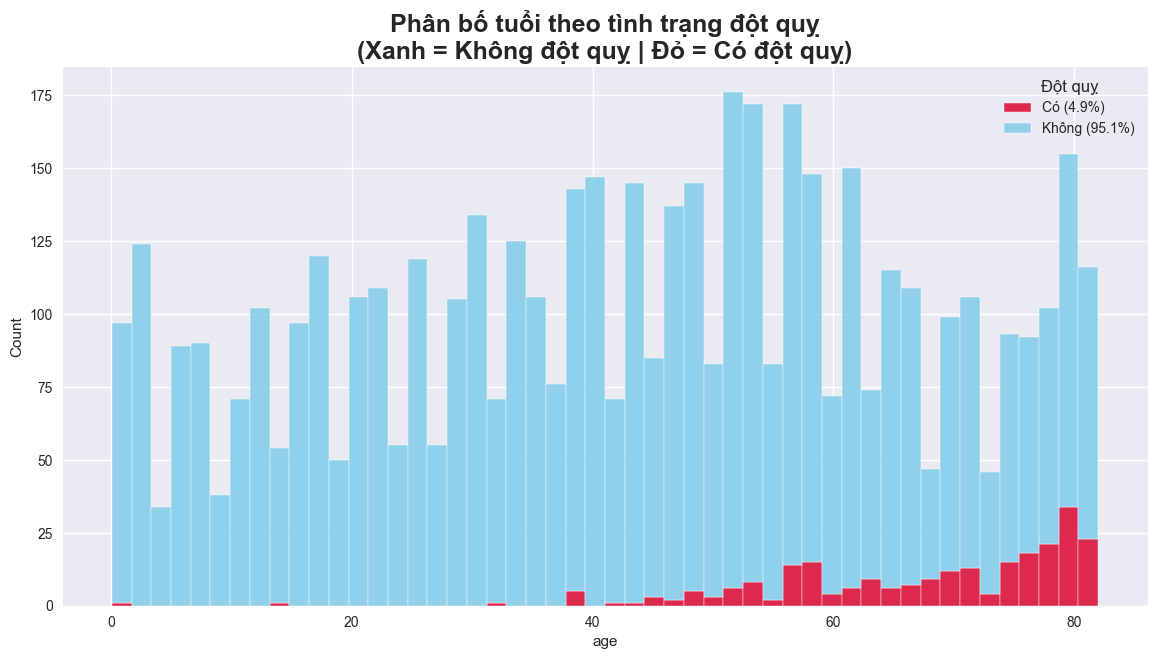

In [32]:
# Cách 2: Đảo lại thứ tự stack để xanh ở trên (dễ nhìn hơn)
plt.figure(figsize=(14,7))
sns.histplot(data=df.sort_values('stroke', ascending=False), 
             x='age', hue='stroke', multiple='stack', bins=50,
             palette={1:'crimson', 0:'skyblue'}, alpha=0.9, edgecolor='white')
plt.title('Phân bố tuổi theo tình trạng đột quỵ\n(Xanh = Không đột quỵ | Đỏ = Có đột quỵ)', fontsize=18)
plt.legend(title='Đột quỵ', labels=['Có (4.9%)', 'Không (95.1%)'])
plt.show()

## 4.3.5.BMI theo tình trạng đột quỵ

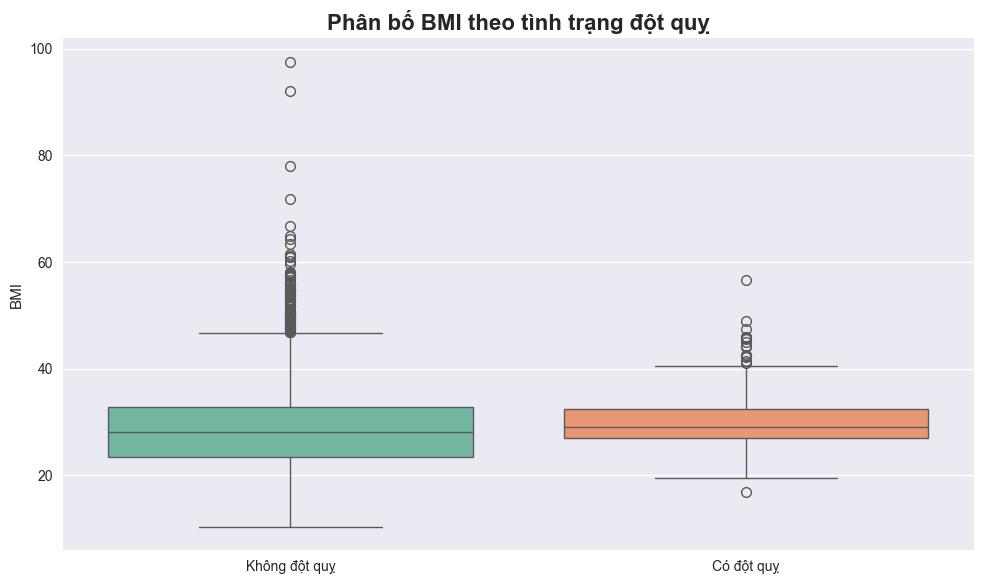

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='stroke', y='bmi', palette='Set2')
plt.title('Phân bố BMI theo tình trạng đột quỵ')
plt.xticks([0, 1], ['Không đột quỵ', 'Có đột quỵ'])
plt.ylabel('BMI')
plt.xlabel('')
plt.tight_layout()
plt.show()

## 4.3.6. Countplot các biến phân loại quan trọng

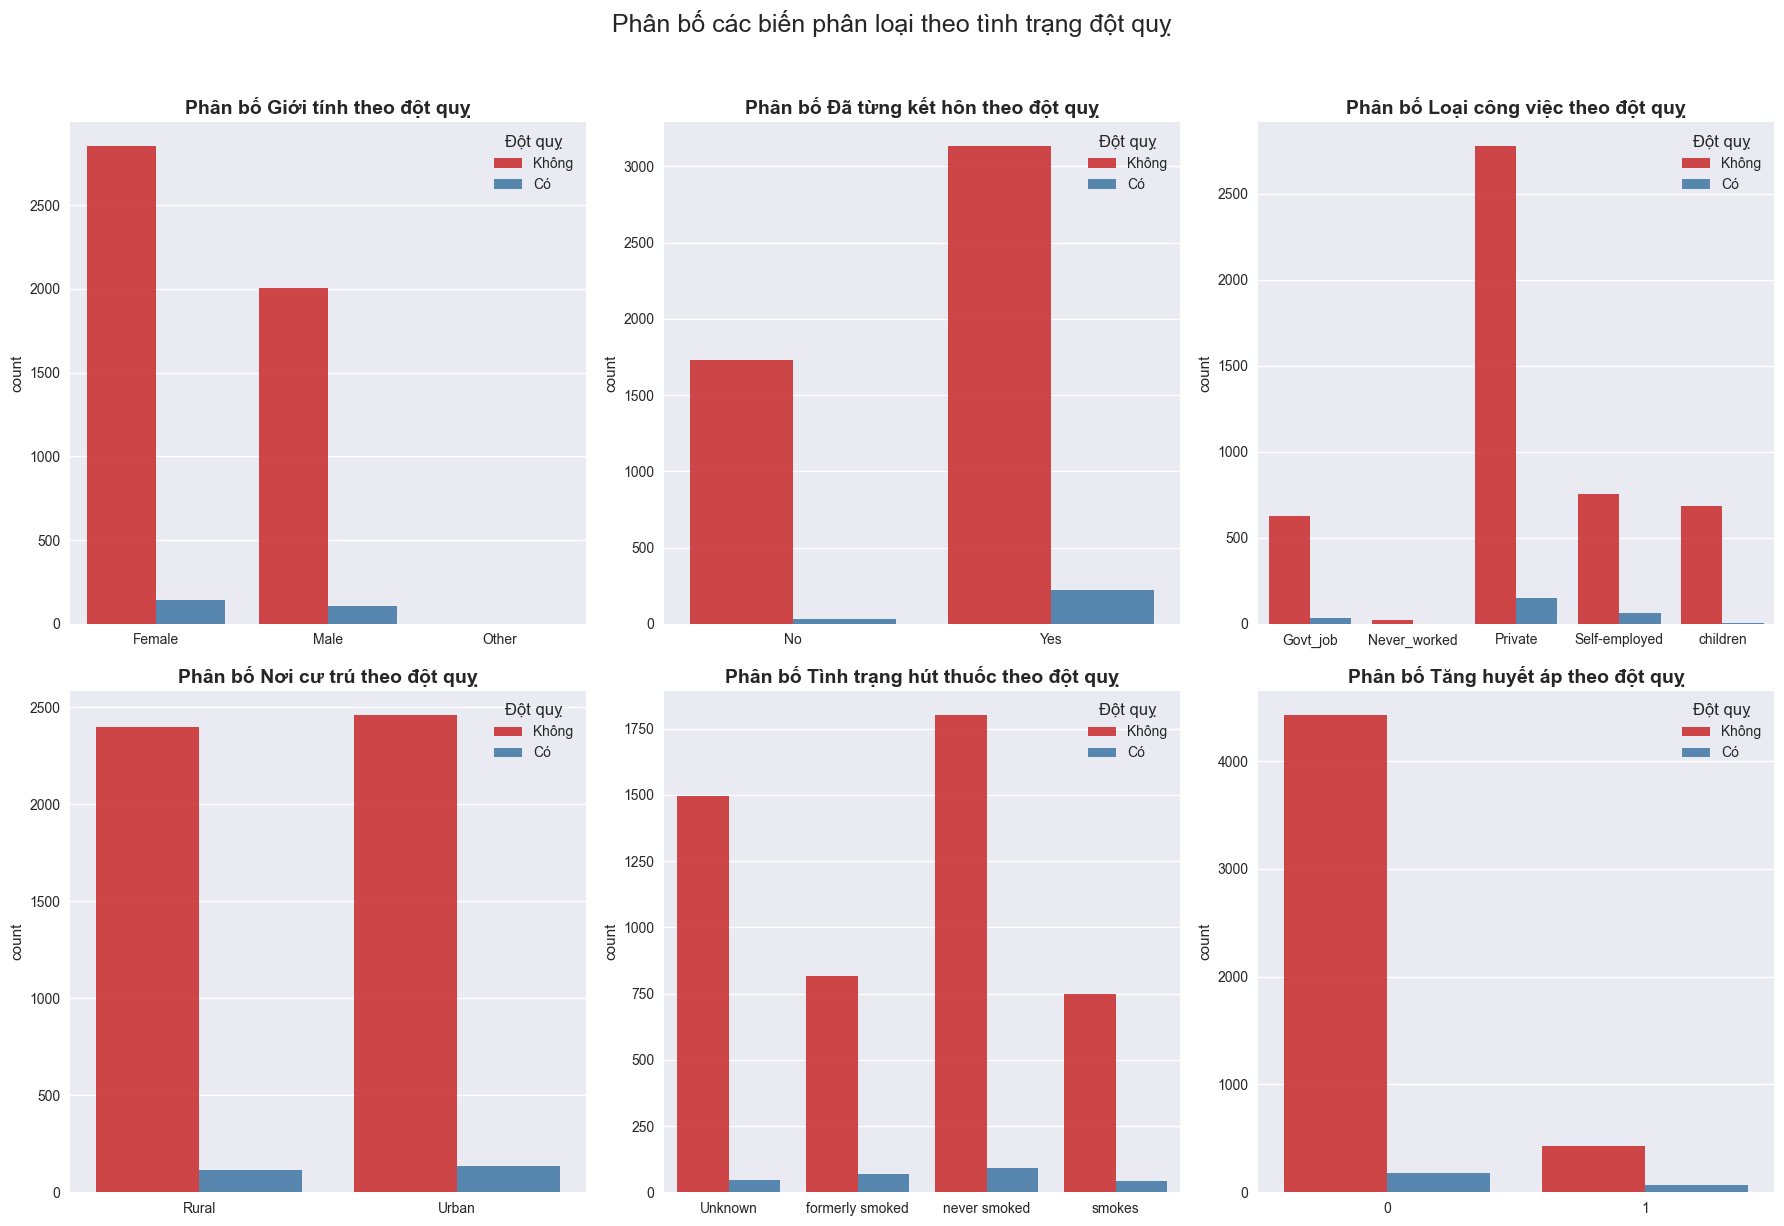

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

cat_plots = [
    ('gender', 'Giới tính'),
    ('ever_married', 'Đã từng kết hôn'),
    ('work_type', 'Loại công việc'),
    ('Residence_type', 'Nơi cư trú'),
    ('smoking_status', 'Tình trạng hút thuốc'),
    ('hypertension', 'Tăng huyết áp')
]

for i, (col, title) in enumerate(cat_plots):
    sns.countplot(data=df, x=col, hue='stroke', ax=axes[i], palette='Set1', alpha=0.9)
    axes[i].set_title(f'Phân bố {title} theo đột quỵ', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].legend(title='Đột quỵ', labels=['Không', 'Có'])

plt.suptitle('Phân bố các biến phân loại theo tình trạng đột quỵ', y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

## 4.3.7. Pairplot các biến số học chính

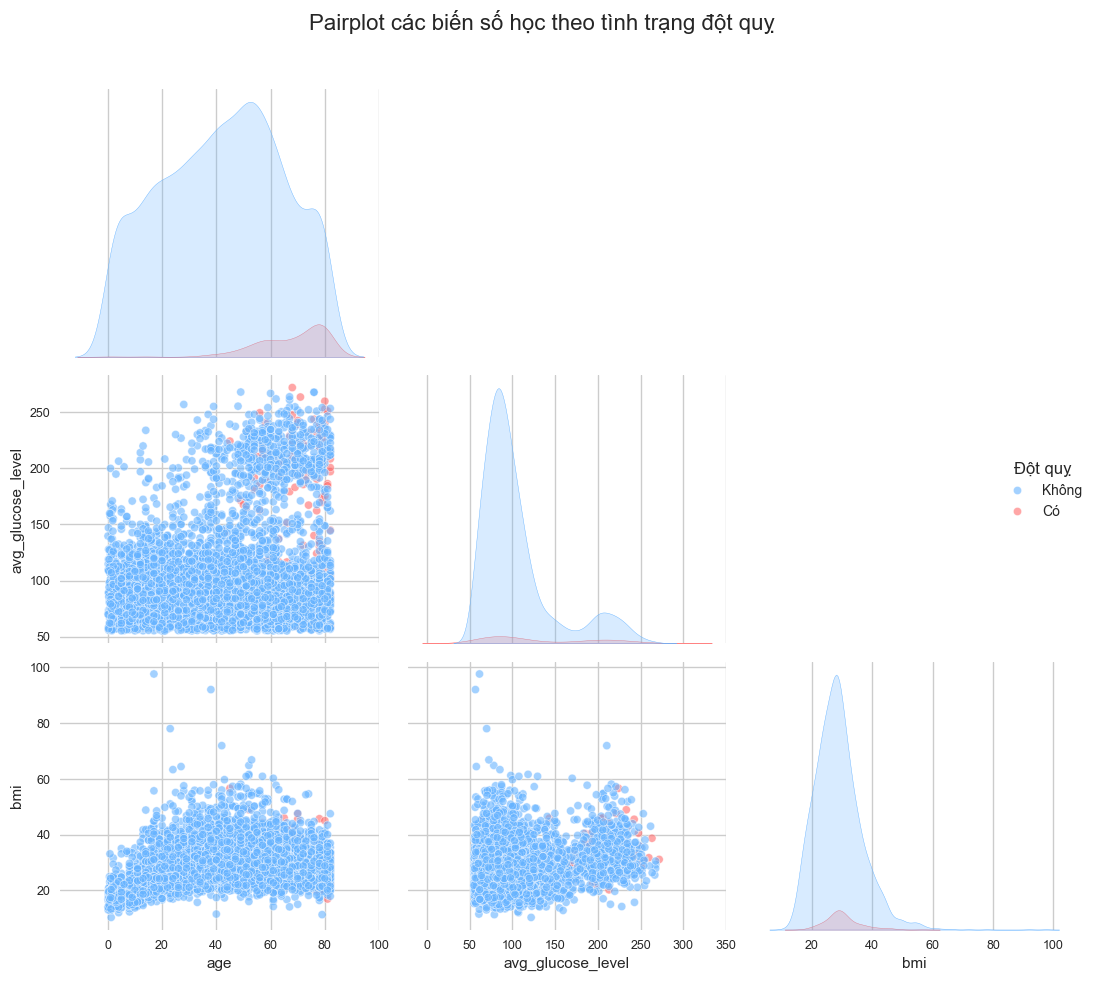

In [33]:
# Cải thiện hiển thị pairplot
plot_df = df[['age', 'avg_glucose_level', 'bmi', 'stroke']].copy()
# đặt nhãn dễ đọc cho legend
plot_df['stroke_label'] = plot_df['stroke'].map({0: 'Không đột quỵ', 1: 'Có đột quỵ'})

sns.set_style('whitegrid')
palette = {'Không đột quỵ': '#66b3ff', 'Có đột quỵ': '#ff6b6b'}

g = sns.pairplot(
    plot_df,
    vars=['age', 'avg_glucose_level', 'bmi'],
    hue='stroke_label',
    palette=palette,
    diag_kind='kde',
    corner=True,
    height=3.2,
    plot_kws={'alpha': 0.6, 's': 35, 'edgecolor': 'w'},
    diag_kws={'shade': True}
)

g.fig.suptitle('Pairplot các biến số học theo tình trạng đột quỵ', y=1.02, fontsize=16)

# Tinh chỉnh font, legend và bố cục để nhìn gọn hơn
for ax in g.axes.flatten():
    if ax is None:
        continue
    ax.tick_params(labelsize=9)
if g._legend is not None:
    g._legend.set_title('Đột quỵ')
    for t, txt in zip(g._legend.texts, ['Không', 'Có']):
        t.set_text(txt)

plt.tight_layout()
plt.show()

## 4.3.8. Tỷ lệ đột quỵ tổng thể

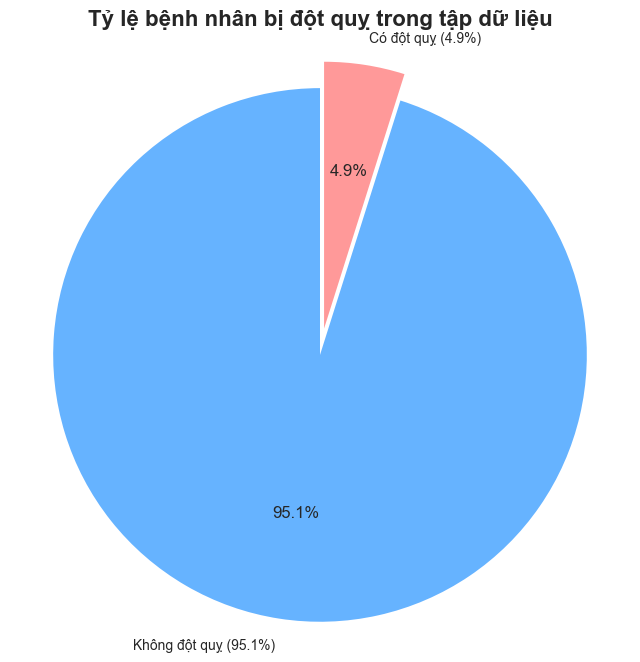

In [25]:
plt.figure(figsize=(8, 8))
stroke_counts = df['stroke'].value_counts()
plt.pie(stroke_counts, labels=['Không đột quỵ (95.1%)', 'Có đột quỵ (4.9%)'], 
        autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'], explode=(0, 0.1))
plt.title('Tỷ lệ bệnh nhân bị đột quỵ trong tập dữ liệu', fontsize=16)
plt.axis('equal')
plt.show()